In [59]:
#%load_ext autoreload
#%autoreload 2
import numpy as np
import pickle
import matplotlib.pyplot as plt
import scipy.optimize as optimize

import kwant
from scipy import linalg as la
from alter_morph.kwant_utilities import crack_hamiltonian_for_contacts_kwant, attach_leads_to_cracked

#from scipy import linalg as la
from alter_morph.hamiltonians import alt_hamiltonian, spectral_function
# from alter_morph.lattice_utilities import alter_lattice_maker,add_contacts
# from alter_morph.mean_field import hartree_fock
# from alter_morph.kwant_utilities import Amorphous

In [ ]:
import sys,os

data_name = 'data/full_phase_diagram_20_V1.pickle'

d = pickle.load(open(os.getcwd()[:-8]+data_name,'rb'))

print(d.keys())
print('fillings: ', d['filling'].shape)
print('Js: ', d['J'].shape)
print('params:', d['params'].shape)
print('\t element [0,0]', d['params'][0,0].keys())
print('data:', d['data'].shape)
print('\t element [0,0]', d['data'][0,0].keys())
print('\t \t element [0,0] numerical params', d['data'][0,0]['numerical_param'].keys())

Js = d['J']
ns = d['filling']


dict_keys(['filling', 'J', 'data', 'params'])
fillings:  (31,)
Js:  (41,)
params: (31, 41)
	 element [0,0] dict_keys(['t1', 't2', 'J', 'filling', 'theta_offset', 'm'])
data: (31, 41)
	 element [0,0] dict_keys(['hparam', 'numerical_param'])
	 element [0,0] numerical params dict_keys(['m_values', 'iteration_steps', 'learning_rate', 'tol_mdiff'])


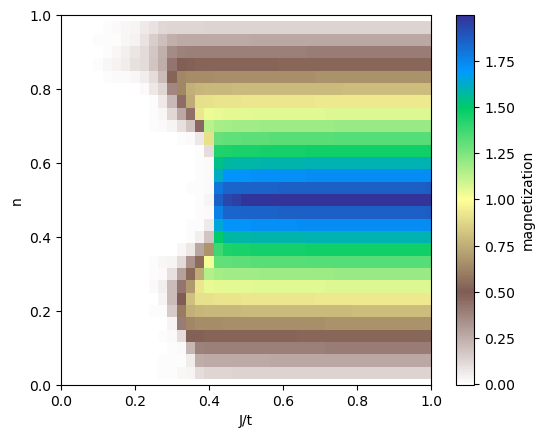

In [27]:
#the magnetizartion
array_magnetization = np.array([[params['m'] for params in x]for x in d['params']]) #.shape (filling, Js, vertices)

fig, ax = plt.subplots(1,1)

#ax.set_title('T/t={0}; Lq={1}'.format(T,Lq))
ax.set_xlabel('J/t')
ax.set_ylabel('n')
ax.set_xlim(Js[0],Js[-1])
ax.set_ylim(ns[0],ns[-1])

extent=[Js[0]-(Js[1]-Js[0])/2,Js[-1]+(Js[1]-Js[0])/2,ns[0]-(ns[1]-ns[0])/2,ns[-1]+(ns[1]-ns[0])/2] #the correct extent

im = ax.imshow(array_magnetization.mean(axis=-1),origin='lower',interpolation='none',extent=extent,cmap='terrain_r')
cbar = fig.colorbar(im, ax=ax,shrink=1)
cbar.set_label('magnetization')


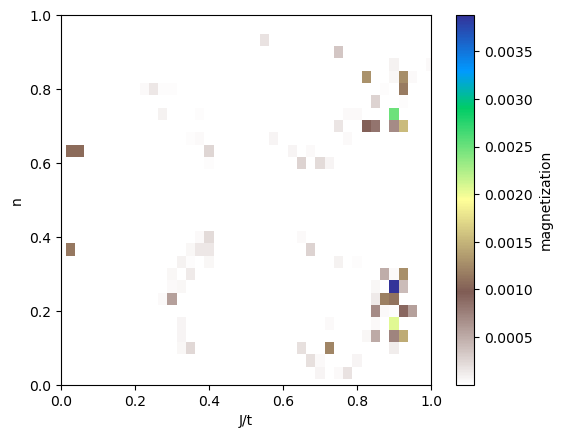

In [28]:
#check convergence

iterations = np.array([[params['numerical_param']['m_values'].shape[0] for params in x]for x in d['data']]) #.shape (filling, Js, vertices)
diffs = np.array([[params['numerical_param']['m_values'][-2] - params['numerical_param']['m_values'][-1] for params in x]for x in d['data']]) #.shape (filling, Js, vertices)
diffs = np.abs(diffs).mean(axis=-1)

fig, ax = plt.subplots(1,1)

#ax.set_title('T/t={0}; Lq={1}'.format(T,Lq))
ax.set_xlabel('J/t')
ax.set_ylabel('n')
ax.set_xlim(Js[0],Js[-1])
ax.set_ylim(ns[0],ns[-1])

extent=[Js[0]-(Js[1]-Js[0])/2,Js[-1]+(Js[1]-Js[0])/2,ns[0]-(ns[1]-ns[0])/2,ns[-1]+(ns[1]-ns[0])/2] #the correct extent

im = ax.imshow(diffs,origin='lower',interpolation='none',extent=extent,cmap='terrain_r')
cbar = fig.colorbar(im, ax=ax,shrink=1)
cbar.set_label('magnetization')


In [29]:
#calculate spin conductance

lattice = pickle.load(open('voronoi_20.pickle','rb'))


lead_symmetry = np.diag([-1,-1,1,1])
for data_column in d['data']:
    for data_entry in data_column:

        hamiltonian = alt_hamiltonian(
            lattice,
            data_entry['hparam']["t1"],
            data_entry['hparam']["t2"],
            data_entry['hparam']["J"],
            data_entry['hparam']['m'],
            theta_offset = data_entry['hparam']['theta_offset']
        )

        #evaluating the Fermi energy
        energies, states = la.eigh(hamiltonian)
        fermi_occupation = np.linspace(0, 1, len(states)) <= data_entry['hparam']['filling']
        local_densities = np.sum(states * states.conj() * fermi_occupation, axis=1)

        n_orbitals = 4
        lead_onsite = np.eye(n_orbitals)
        lead_coupling = np.eye(n_orbitals)

        contact_lattice, k_lattice, k_system, contact_vertices = (
            crack_hamiltonian_for_contacts_kwant(lattice, hamiltonian)
        )
        kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
            contact_lattice, k_lattice, k_system, contact_vertices, lead_onsite, lead_coupling, lead_symmetry
        )

        k_system_f = k_system.finalized()
        smatrix = kwant.smatrix(k_system_f)
        g = np.array([[smatrix.transmission((1,j),(0,i)) for j in range(2)] for i in range(2)])
        data_entry['spin_cond'] = g
pickle.dump(d, open(os.getcwd()[:-8] + data_name, 'wb'))

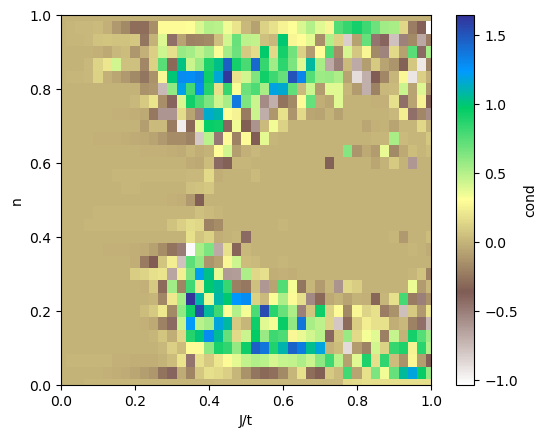

In [39]:
#the spin_cond
array_spin_cond = np.array([[params['spin_cond'] for params in x]for x in d['data']]) #.shape (filling, Js, 2,2)
array_g0 = array_spin_cond[:,:,0,0] + array_spin_cond[:,:,1,1]
array_gspin = array_spin_cond[:,:,0,0] - array_spin_cond[:,:,1,1]

fig, ax = plt.subplots(1,1)

#ax.set_title('T/t={0}; Lq={1}'.format(T,Lq))
ax.set_xlabel('J/t')
ax.set_ylabel('n')
ax.set_xlim(Js[0],Js[-1])
ax.set_ylim(ns[0],ns[-1])

extent=[Js[0]-(Js[1]-Js[0])/2,Js[-1]+(Js[1]-Js[0])/2,ns[0]-(ns[1]-ns[0])/2,ns[-1]+(ns[1]-ns[0])/2] #the correct extent

im = ax.imshow(array_gspin,origin='lower',interpolation='none',extent=extent,cmap='terrain_r')
cbar = fig.colorbar(im, ax=ax,shrink=1)
cbar.set_label('cond')

In [60]:
g_spin = []
fermi_energies = []
spectral_functions_up = []
spectral_functions_dw = []
idx_n = 4
print(ns[idx_n])

for j in range(d['data'].shape[1]):

    data_entry = d['data'][idx_n,j]

    hamiltonian = alt_hamiltonian(
        lattice,
        data_entry['hparam']["t1"],
        data_entry['hparam']["t2"],
        data_entry['hparam']["J"],
        data_entry['hparam']['m'],
        theta_offset = data_entry['hparam']['theta_offset']
    )

    #evaluating the Fermi energy
    energies, states = la.eigh(hamiltonian)
    fermi_energy = energies[int(data_entry['hparam']['filling']*len(energies))]


    n_orbitals = 4
    lead_onsite = np.eye(n_orbitals)
    lead_coupling = np.eye(n_orbitals)

    contact_lattice, k_lattice, k_system, contact_vertices = (
        crack_hamiltonian_for_contacts_kwant(lattice, hamiltonian)
    )
    kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
        contact_lattice, k_lattice, k_system, contact_vertices, lead_onsite, lead_coupling, lead_symmetry
    )

    ##evaluate at fermi_energie!

    k_system_f = k_system.finalized()
    smatrix = kwant.smatrix(k_system_f,energy=fermi_energy)
    g = np.array([[smatrix.transmission((1,j),(0,i)) for j in range(2)] for i in range(2)])

    g_spin.append(g[0,0]-g[1,1])
    fermi_energies.append(fermi_energy)


    spectral_functions_up.append(spectral_function(lattice, energies, states, fermi_energy,local_projector=np.array([1, 1, 0, 0])))
    spectral_functions_dw.append(spectral_function(lattice, energies, states, fermi_energy,local_projector=np.array([0, 0, 1, 1])))

#print(fermi_energy)
#print(g)

0.13333333333333333


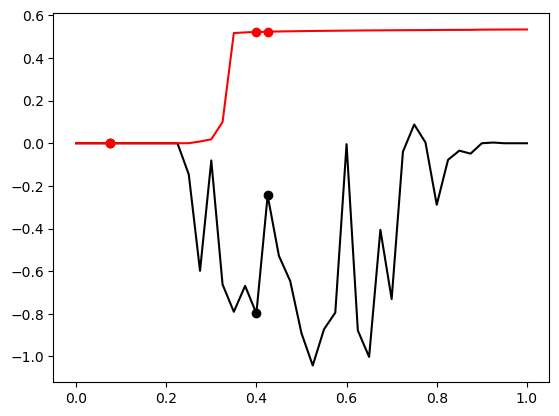

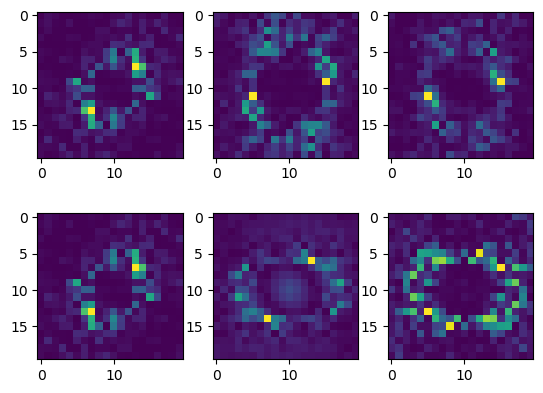

In [117]:
for x in [spectral_functions_up,spectral_functions_dw,fermi_energies,g_spin,Js]:
    x = np.array(x)
g_spin = np.array(g_spin)

idx_Js = np.array([3, 16, 17],dtype=int)


plt.plot(Js,g_spin,'k')
plt.plot(Js[idx_Js],g_spin[idx_Js],'ko')

#plt.plot(Js,fermi_energies)
plt.plot(Js,array_magnetization[idx_n].mean(axis=-1),'r')
plt.plot(Js[idx_Js],array_magnetization[idx_n,idx_Js].mean(axis=-1),'ro')


fig,axs = plt.subplots(2,len(idx_Js))

for j,idx_J in enumerate(idx_Js):
    
    axs[0,j].imshow(np.abs(spectral_functions_up[idx_J]))
    axs[1,j].imshow(np.abs(spectral_functions_dw[idx_J]))

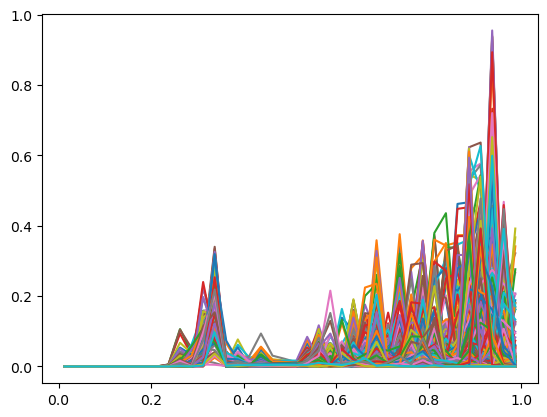

In [ ]:
dJs = (Js[1:] + Js[:-1])/2

dg_spin = (g_spin[1:] - g_spin[:-1])/2
dm = (array_magnetization[idx_n,1:] - array_magnetization[idx_n,:-1])/2


plt.plot(dJs,np.abs(dm));



1.5283519828430514


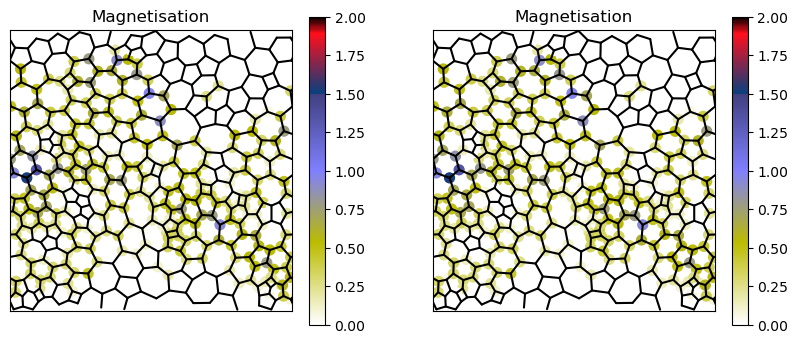

In [130]:
from koala import plotting as pl

idx_Js = np.array([16, 17],dtype=int)

dm = 100*(array_magnetization[idx_n,idx_Js[1]] - array_magnetization[idx_n,idx_Js[0]])/2
print(dm.max())


fig, axs = plt.subplots(1, len(idx_Js), figsize=(len(idx_Js)*5, 4))
for idx_J,ax in zip(idx_Js,axs):
    pl.plot_edges(lattice, ax=ax)
    im = ax.scatter(
        lattice.vertices.positions[:, 0],
        lattice.vertices.positions[:, 1],
        c=dm,#array_magnetization[idx_n,idx_J],
        cmap="gist_stern_r",
        s=50,
        vmin=0,
        vmax=2,
    )
    plt.colorbar(im, ax=ax)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("Magnetisation")